# AutoML Research Experiment Analysis

This notebook analyzes `results.tsv` for the classical ML experiment loop in this repo. It is designed for the `automl-research` workflow inspired by Karpathy-style autoresearch: propose one change, run it, evaluate it, and keep only real improvements.


In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
from IPython.display import display

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_colwidth", 120)

df = pd.read_csv("results.tsv", sep="\t").copy()
df["cv_score"] = pd.to_numeric(df["cv_score"], errors="coerce")
df["runtime_seconds"] = pd.to_numeric(df["runtime_seconds"], errors="coerce")
df["holdout_score_num"] = pd.to_numeric(df["holdout_score"], errors="coerce")
df["timestamp"] = pd.to_datetime(df["timestamp"], errors="coerce")
df["kept"] = df["kept"].fillna("").astype(str).str.strip().str.lower()
df["metric_name"] = df["metric_name"].fillna("unknown")

status_map = {
    "yes": "kept",
    "no": "reverted",
    "ref": "baseline",
    "": "incomplete",
}
df["status"] = df["kept"].map(status_map).fillna("incomplete")
df["has_holdout"] = df["holdout_score_num"].notna()

def short_description(text):
    text = str(text).strip()
    if not text:
        return ""
    replacements = [
        ("naive baseline (predict majority)", "majority baseline"),
        ("logistic regression", "logreg"),
        ("LogisticRegressionCV", "logreg cv"),
        ("HistGradientBoosting", "hist gb"),
        ("RandomForest", "random forest"),
        ("soft voting ensemble", "voting ensemble"),
        ("add ", ""),
        ("default-ish params", "default params"),
        (" from Name", ""),
        (" (Mr/Mrs/Miss/Master)", " titles"),
        (" one-hot", ""),
        (" and ", " + "),
        (" (", ": "),
        (")", ""),
    ]
    lowered = text
    for old, new in replacements:
        lowered = lowered.replace(old, new)
    lowered = " ".join(lowered.replace("+", " + ").replace(":", ": ").split())
    return lowered[:48] + "..." if len(lowered) > 48 else lowered

df["short_description"] = df["description"].map(short_description)

metric_name = df["metric_name"].dropna().iloc[0] if not df.empty else "metric"
higher_is_better = metric_name not in {"val_logloss", "val_rmse", "val_mse"}
metric_direction = "maximize" if higher_is_better else "minimize"
df["running_best"] = df["cv_score"].cummax() if higher_is_better else df["cv_score"].cummin()
df["improved_vs_prev"] = df["cv_score"].diff().fillna(0)
df["improved_vs_best_before"] = df["cv_score"] - df["running_best"].shift(1)

print(f"Experiments logged: {len(df)}")
print(f"Metric tracked: {metric_name}")
print(f"Metric direction: {metric_direction}")
print(f"Statuses: {df['status'].value_counts().to_dict()}")

display(df.head())


Experiments logged: 20
Metric tracked: val_accuracy
Metric direction: maximize
Statuses: {'reverted': 8, 'kept': 7, 'incomplete': 4, 'baseline': 1}


,experiment,description,metric_name,cv_score,holdout_score,kept,runtime_seconds,timestamp,holdout_score_num,status,has_holdout,short_description,running_best,improved_vs_prev,improved_vs_best_before
0,0,naive baseline (predict majority),val_accuracy,0.616163,-,ref,0.1,2026-03-10 21:47:46,NaN,baseline,False,majority baseline,0.616163,0.000000,NaN
1,1,logistic regression: sex+pclass+age+fare+family+embarked,val_accuracy,0.796880,-,yes,1.0,2026-03-10 21:47:46,NaN,kept,False,logreg: sex + pclass + age + fare + family + emb...,0.796880,0.180717,0.180717
2,2,add title extraction from Name (Mr/Mrs/Miss/Master),val_accuracy,0.828272,-,yes,2.2,2026-03-11 03:46:45,NaN,kept,False,title extraction titles,0.828272,0.031392,0.031392
3,3,HistGradientBoosting (default-ish params),val_accuracy,0.819289,-,no,1.7,2026-03-11 03:47:30,NaN,reverted,False,hist gb: default params,0.828272,-0.008983,-0.008983
4,4,LogisticRegressionCV (tune C via inner CV),val_accuracy,0.832766,-,yes,1.7,2026-03-11 03:48:08,NaN,kept,False,logreg cv: tune C via inner CV,0.832766,0.013477,0.004494


## Outcome Summary

The `kept` column is the experiment decision log for this project:

- `ref`: reference baseline
- `yes`: experiment improved enough to keep
- `no`: experiment was tried and reverted
- blank: run logged without a final keep/revert decision yet


In [34]:
status_counts = df["status"].value_counts().rename_axis("status").reset_index(name="count")
display(status_counts)

kept = df[df["status"] == "kept"].copy()
reverted = df[df["status"] == "reverted"].copy()
baseline = df[df["status"] == "baseline"].copy()
pending = df[df["status"] == "incomplete"].copy()

baseline_score = baseline["cv_score"].iloc[0] if not baseline.empty else np.nan
best_idx = df["cv_score"].idxmax() if higher_is_better and not df["cv_score"].isna().all() else df["cv_score"].idxmin()
best_row = df.loc[best_idx] if best_idx is not None else None
decision_count = len(kept) + len(reverted)

print(f"Baseline score: {baseline_score:.6f}")
if best_row is not None:
    delta = best_row["cv_score"] - baseline_score
    if not higher_is_better:
        delta = -delta
    print(f"Best score:     {best_row['cv_score']:.6f} (experiment {int(best_row['experiment'])})")
    print(f"Improvement:    {delta:+.6f} ({delta / baseline_score:.2%} vs baseline)")

if decision_count:
    print(f"Kept rate:      {len(kept)}/{decision_count} = {len(kept) / decision_count:.1%}")

if not pending.empty:
    print(f"Open decisions: {len(pending)}")

print(f"Median runtime: {df['runtime_seconds'].dropna().median():.2f}s")


,status,count
0,reverted,8
1,kept,7
2,incomplete,4
3,baseline,1


Baseline score: 0.616163
Best score:     0.852972 (experiment 17)
Improvement:    +0.236809 (38.43% vs baseline)
Kept rate:      7/15 = 46.7%
Open decisions: 4
Median runtime: 1.90s


In [35]:
timeline = df[["experiment", "short_description", "status", "cv_score", "holdout_score", "runtime_seconds", "timestamp"]].copy()
timeline = timeline.rename(columns={"short_description": "description"})
timeline["gain_vs_baseline"] = timeline["cv_score"] - baseline_score
if not higher_is_better:
    timeline["gain_vs_baseline"] = -timeline["gain_vs_baseline"]
timeline["gain_vs_prev"] = df["improved_vs_prev"]
if not higher_is_better:
    timeline["gain_vs_prev"] = -timeline["gain_vs_prev"]
display(timeline)


,experiment,description,status,cv_score,holdout_score,runtime_seconds,timestamp,gain_vs_baseline,gain_vs_prev
0,0,majority baseline,baseline,0.616163,-,0.1,2026-03-10 21:47:46,0.000000,0.000000
1,1,logreg: sex + pclass + age + fare + family + emb...,kept,0.796880,-,1.0,2026-03-10 21:47:46,0.180717,0.180717
2,2,title extraction titles,kept,0.828272,-,2.2,2026-03-11 03:46:45,0.212109,0.031392
3,3,hist gb: default params,reverted,0.819289,-,1.7,2026-03-11 03:47:30,0.203126,-0.008983
4,4,logreg cv: tune C via inner CV,kept,0.832766,-,1.7,2026-03-11 03:48:08,0.216603,0.013477
5,5,cabin deck + has_cabin,reverted,0.824901,-,1.8,2026-03-11 03:48:37,0.208738,-0.007865
6,6,pclass*female + age*pclass interactions,reverted,0.828278,-,1.9,2026-03-11 03:49:05,0.212115,0.003377
7,7,"random forest: 500 trees, depth=7",reverted,0.831649,-,2.3,2026-03-11 03:49:36,0.215486,0.003371
8,8,is_child + is_elderly age bins,reverted,0.830525,-,1.7,2026-03-11 03:50:12,0.214362,-0.001124
9,9,ticket_group_size from combined train + test,reverted,0.831643,-,1.7,2026-03-11 03:51:00,0.215480,0.001118


## Score Trajectory

This chart keeps the original autoresearch-style design: discarded runs are faint background dots, kept improvements are highlighted in green, and the running-best frontier is shown as a step line with annotations.


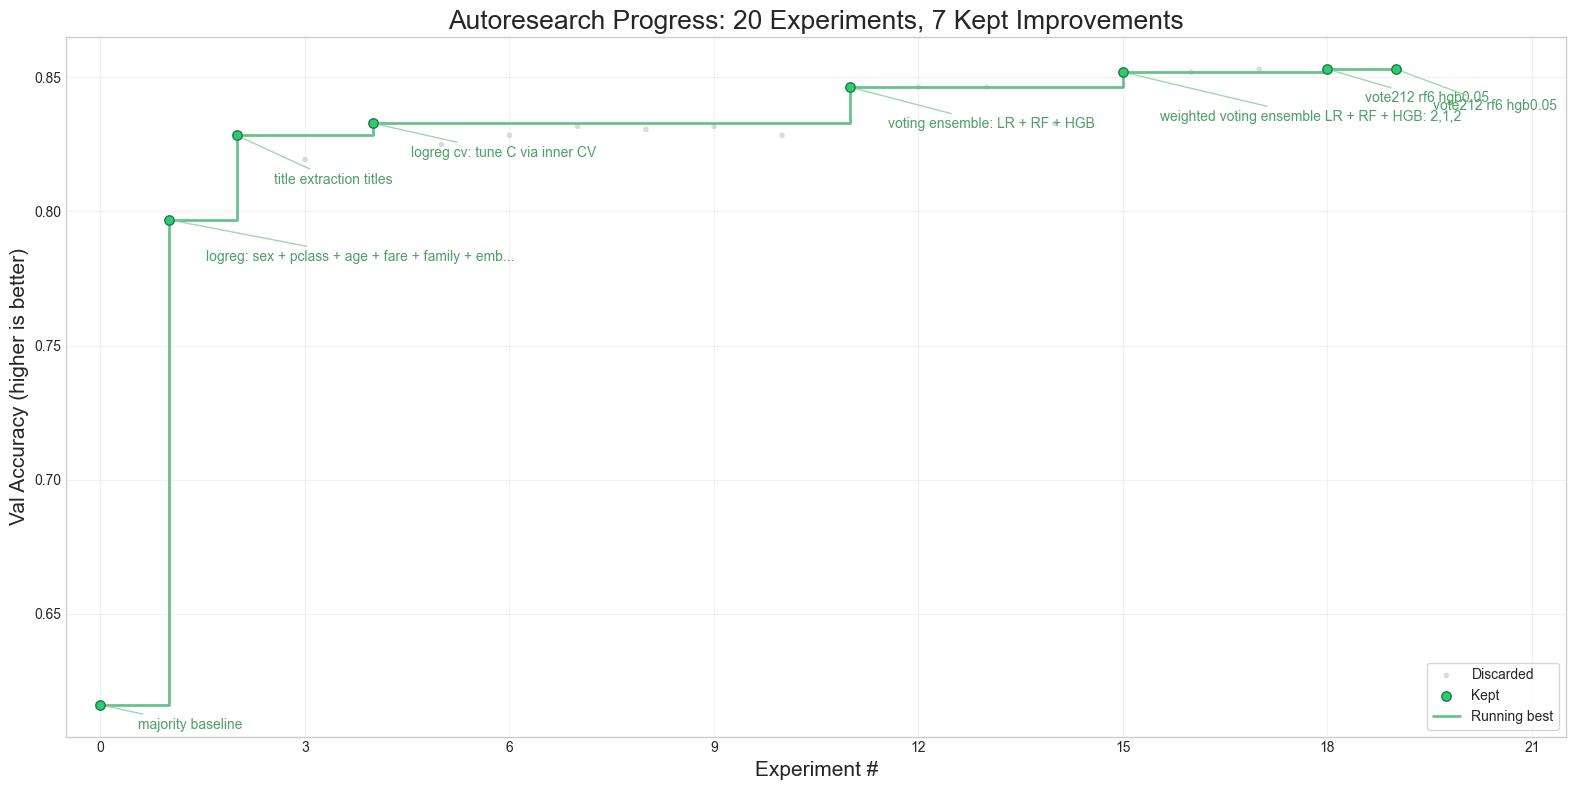

In [38]:
frontier = df[df["status"].isin(["baseline", "kept"])].copy()
frontier = frontier[frontier["cv_score"] == frontier["running_best"]].copy()
discarded = df[~df.index.isin(frontier.index)].copy()

fig, ax = plt.subplots(figsize=(16, 8))

ax.scatter(
    discarded["experiment"],
    discarded["cv_score"],
    c="#bdbdbd",
    s=16,
    alpha=0.55,
    label="Discarded",
    edgecolors="none",
    zorder=2,
)

ax.scatter(
    frontier["experiment"],
    frontier["cv_score"],
    c="#2ecc71",
    s=46,
    label="Kept",
    edgecolors="#1f7a4d",
    linewidths=1,
    zorder=4,
)

ax.step(
    frontier["experiment"],
    frontier["running_best"],
    where="post",
    color="#68c28e",
    linewidth=2,
    label="Running best",
    zorder=3,
)

y_min, y_max = df["cv_score"].min(), df["cv_score"].max()
y_span = max(y_max - y_min, 1e-6)

for idx, (_, row) in enumerate(frontier.iterrows()):
    desc = row["short_description"]
    label_y = row["cv_score"] - (0.035 + 0.012 * (idx % 3)) * y_span
    label_y = max(label_y, y_min - 0.02 * y_span)
    label_x = row["experiment"] + 0.55
    ax.annotate(
        desc,
        xy=(row["experiment"], row["cv_score"]),
        xytext=(label_x, label_y),
        textcoords="data",
        fontsize=10,
        color="#4f9f69",
        ha="left",
        va="top",
        arrowprops={"arrowstyle": "-", "color": "#8fd19e", "lw": 1, "alpha": 0.85},
    )

direction_text = "higher is better" if higher_is_better else "lower is better"
ax.set_title(f"Autoresearch Progress: {len(df)} Experiments, {len(kept)} Kept Improvements", fontsize=19)
ax.set_xlabel("Experiment #", fontsize=15)
ax.set_ylabel(f"{metric_name.replace('_', ' ').title()} ({direction_text})", fontsize=15)
ax.set_xlim(df["experiment"].min() - 0.5, df["experiment"].max() + 2.5)
ax.xaxis.set_major_locator(MaxNLocator(integer=True))
ax.grid(True, alpha=0.25)
ax.legend(loc="lower right", frameon=True)

plt.tight_layout()
plt.show()


In [37]:
if not kept.empty:
    kept_view = kept[["experiment", "short_description", "cv_score", "runtime_seconds", "timestamp"]].copy()
    kept_view = kept_view.rename(columns={"short_description": "description"})
    kept_view["gain_vs_prev_kept"] = kept_view["cv_score"].diff().fillna(kept_view["cv_score"] - baseline_score)
    if not higher_is_better:
        kept_view["gain_vs_prev_kept"] = -kept_view["gain_vs_prev_kept"]
    kept_view = kept_view.sort_values("cv_score", ascending=not higher_is_better)
    display(kept_view)
else:
    print("No kept experiments recorded yet.")

if df["has_holdout"].any():
    holdout_view = df.loc[df["has_holdout"], ["experiment", "short_description", "cv_score", "holdout_score_num"]].copy()
    holdout_view = holdout_view.rename(columns={"short_description": "description"})
    holdout_view["cv_minus_holdout"] = holdout_view["cv_score"] - holdout_view["holdout_score_num"]
    display(holdout_view)
else:
    print("No numeric holdout scores logged yet.")


,experiment,description,cv_score,runtime_seconds,timestamp,gain_vs_prev_kept
18,18,vote212 rf6 hgb0.05,0.852972,2.5,2026-03-11 06:34:12,0.001136
19,19,vote212 rf6 hgb0.05,0.852972,2.5,2026-03-11 06:36:32,0.000000
15,15,"weighted voting ensemble LR + RF + HGB: 2,1,2",0.851836,2.4,2026-03-11 06:03:18,0.005599
11,11,voting ensemble: LR + RF + HGB,0.846237,2.7,2026-03-11 03:52:37,0.013471
4,4,logreg cv: tune C via inner CV,0.832766,1.7,2026-03-11 03:48:08,0.004494
2,2,title extraction titles,0.828272,2.2,2026-03-11 03:46:45,0.031392
1,1,logreg: sex + pclass + age + fare + family + emb...,0.796880,1.0,2026-03-10 21:47:46,0.180717


No numeric holdout scores logged yet.


## Takeaways

This notebook is now aligned with the `automl-research` loop:

- it reads experiment metadata from `results.tsv`
- it measures score improvement against the baseline and the running best
- it separates kept, reverted, baseline, and undecided runs
- it surfaces runtime and holdout coverage instead of LM-specific metrics like `val_bpb` or memory use
